### DECISION TREE
Objective:\
The objective of this assignment is to apply Decision Tree Classification to a given dataset, analyse the performance of the model, and interpret the results.\
#### Tasks:
1. Data Preparation:\
Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy).
2. Exploratory Data Analysis (EDA):\
Perform exploratory data analysis to understand the structure of the dataset.\
Check for missing values, outliers, and inconsistencies in the data.\
Visualize the distribution of features, including histograms, box plots, and correlation matrices.
3. Feature Engineering:\
If necessary, perform feature engineering techniques such as encoding categorical variables, scaling numerical features, or handling missing values.
4. Decision Tree Classification:\
Split the dataset into training and testing sets (e.g., using an 80-20 split).\
Implement a Decision Tree Classification model using a library like scikit-learn.\
Train the model on the training set and evaluate its performance on the testing set using appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC).
5. Hyperparameter Tuning:\
Perform hyperparameter tuning to optimize the Decision Tree model. Experiment with different hyperparameters such as maximum depth, minimum samples split, and criterion.
6. Model Evaluation and Analysis:\
Analyse the performance of the Decision Tree model using the evaluation metrics obtained.\
Visualize the decision tree structure to understand the rules learned by the model and identify important features
#### Interview Questions:
1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?
2. What is the difference between the Label encoding and One-hot encoding?


# 1:Data Preparation

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report)

# Load the dataset
data = pd.read_excel("heart_disease.xlsx",sheet_name="Heart_disease")

print("\nFirst 5 rows of the dataset:")
print(data.head())

print("\nDataset Information:")
print(data.info())



First 5 rows of the dataset:
   age   sex               cp  trestbps  chol    fbs         restecg  thalch  \
0   63  Male   typical angina       145   233   True  lv hypertrophy     150   
1   41  Male  atypical angina       135   203  False          normal     132   
2   57  Male     asymptomatic       140   192  False          normal     148   
3   52  Male   typical angina       118   186  False  lv hypertrophy     190   
4   57  Male     asymptomatic       110   201  False          normal     126   

   exang  oldpeak        slope          thal  num  
0  False      2.3  downsloping  fixed defect    0  
1  False      0.0         flat  fixed defect    0  
2  False      0.4         flat  fixed defect    0  
3  False      0.0         flat  fixed defect    0  
4   True      1.5         flat  fixed defect    0  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------

# 2:Exploratory Data Analysis (EDA)

In [18]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
data['oldpeak'] = imputer.fit_transform(data[['oldpeak']])
data['oldpeak']

0      2.3
1      0.0
2      0.4
3      0.0
4      1.5
      ... 
903    1.5
904    3.0
905    2.5
906    0.5
907    0.5
Name: oldpeak, Length: 908, dtype: float64

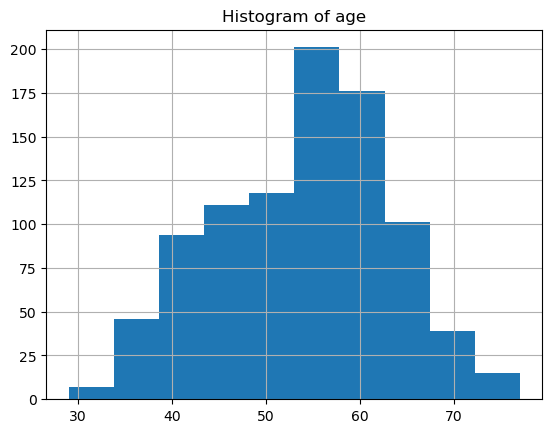

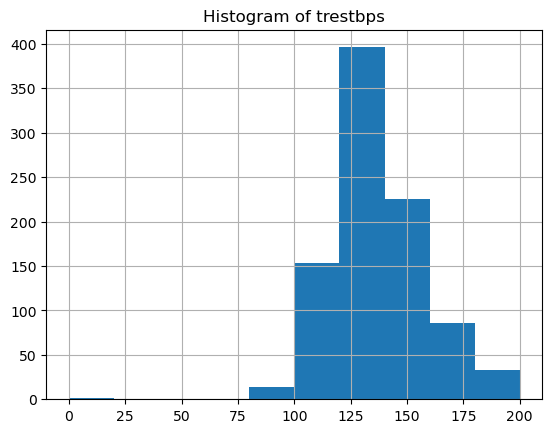

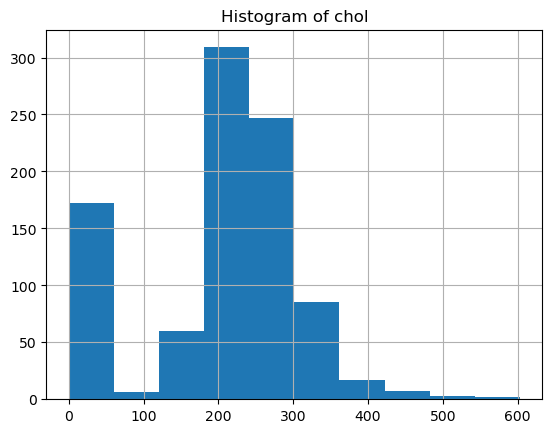

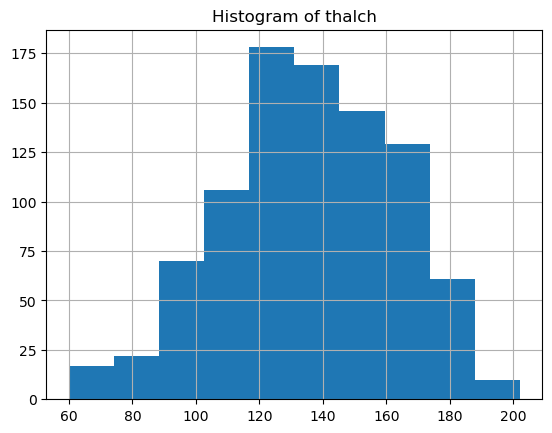

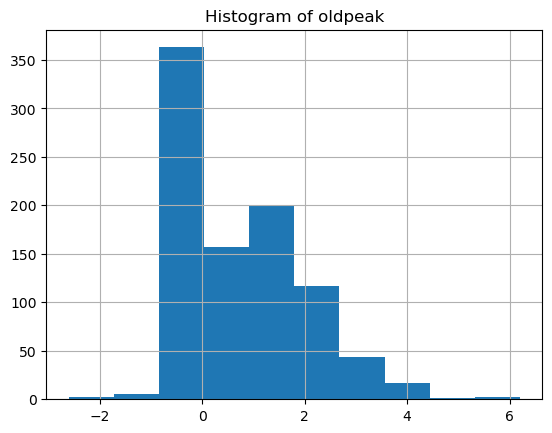

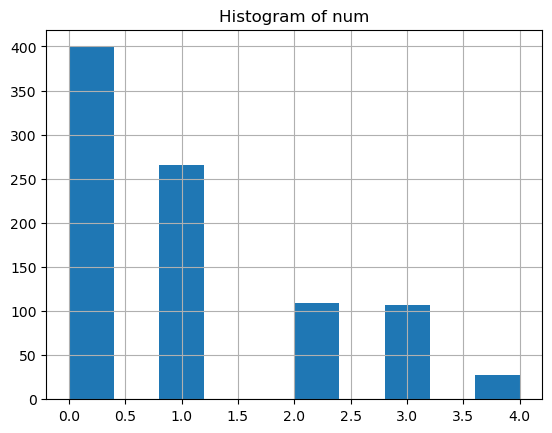

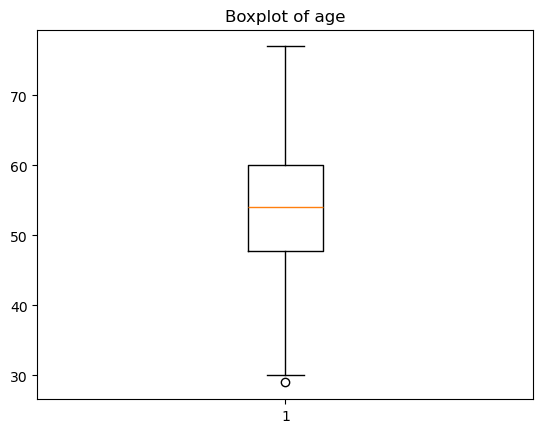

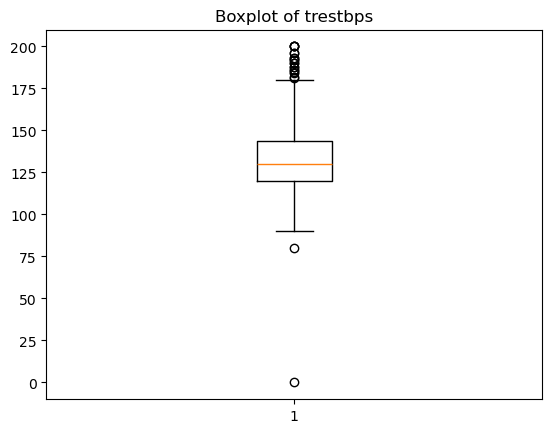

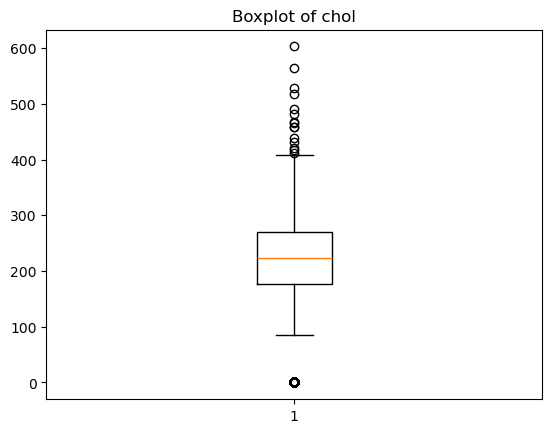

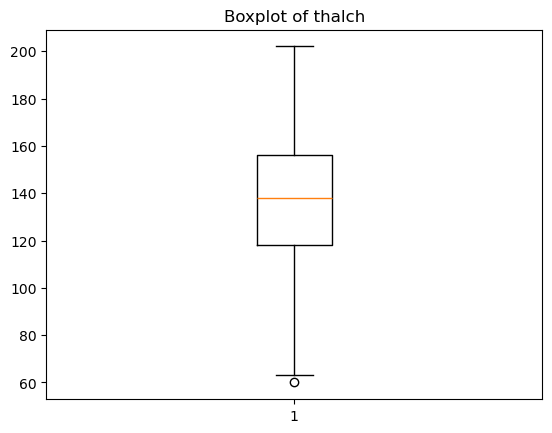

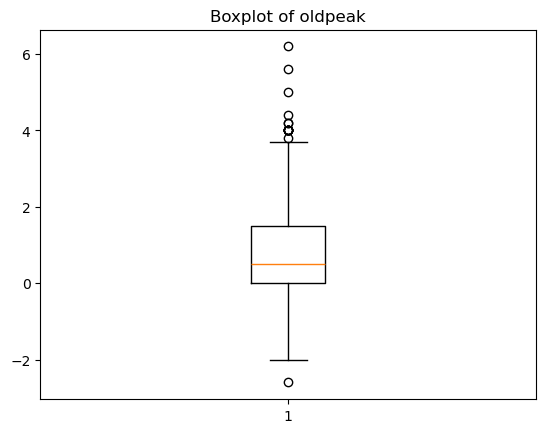

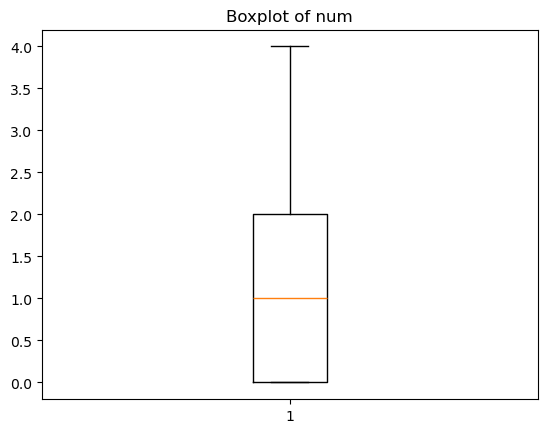

In [19]:
import matplotlib.pyplot as plt

num_cols = data.select_dtypes(include='number').columns

for col in num_cols:
    plt.figure()
    data[col].hist()
    plt.title(f"Histogram of {col}")
    plt.show()

for col in num_cols:
    plt.figure()
    plt.boxplot(data[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

Target Variable Distribution:
sex
Male      718
Female    190
Name: count, dtype: int64


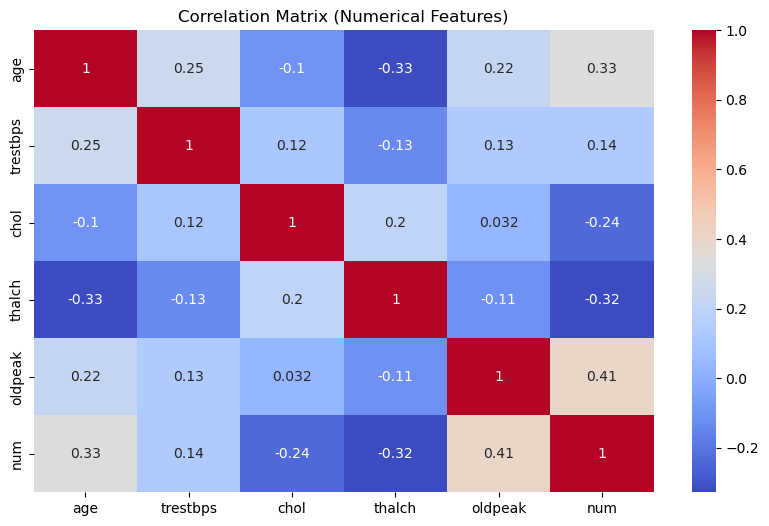

In [5]:
print("\nMissing Values:")
print(data.isnull().sum())

print("\nTarget Variable Distribution:")
print(data.iloc[:,1].value_counts())

# Correlation Matrix (Numerical Features Only)
numeric_data = data.select_dtypes(include=np.number)

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_data.corr(), cmap="coolwarm", annot=True)
plt.title("Correlation Matrix (Numerical Features)")
plt.show()

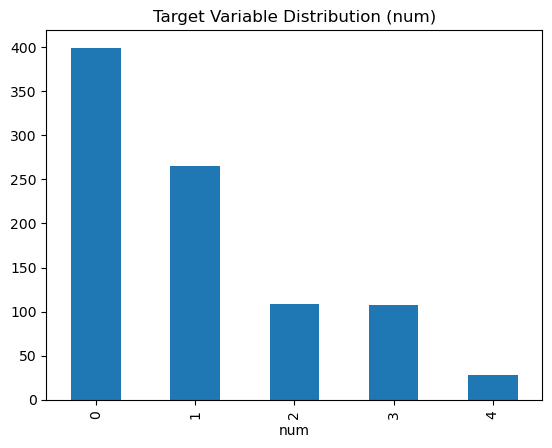

In [6]:
data['num'].value_counts().plot(kind='bar', title='Target Variable Distribution (num)')
plt.show()

## 3: Feature Engineering

In [7]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# 3.2 Encoding Categorical Features

for col in X.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
print("\nCategorical variables encoded.")

# 3.3 Feature Scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Numerical feature scaling completed using StandardScaler.")

# 3.4 Train–Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

print("Train–Test split completed.")


Categorical variables encoded.
Numerical feature scaling completed using StandardScaler.
Train–Test split completed.


## **4: Decision Tree Classification**

In [8]:
# Decision Tree Model
dt_model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42)

# Train model
dt_model.fit(X_train, y_train)

# Predictions
y_pred = dt_model.predict(X_test)

print("\nDecision Tree Model Performance:")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="macro"))
print("Recall   :", recall_score(y_test, y_pred, average="macro"))
print("F1 Score :", f1_score(y_test, y_pred, average="macro"))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Decision Tree Model Performance:
Accuracy : 0.489010989010989
Precision: 0.34533171329648826
Recall   : 0.3511322796700156
F1 Score : 0.34565359477124186

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.69      0.72        80
           1       0.47      0.43      0.45        53
           2       0.15      0.18      0.17        22
           3       0.25      0.29      0.27        21
           4       0.10      0.17      0.12         6

    accuracy                           0.49       182
   macro avg       0.35      0.35      0.35       182
weighted avg       0.52      0.49      0.50       182



In [9]:
from sklearn.metrics import roc_auc_score

# Predict probabilities for base model
y_pred_proba_base = dt_model.predict_proba(X_test)

roc_auc_base = roc_auc_score(
    y_test,
    y_pred_proba_base,
    multi_class='ovr',
    average='weighted'
)

print("Base Decision Tree ROC-AUC:", roc_auc_base)


Base Decision Tree ROC-AUC: 0.6607707091477091


In [10]:
# Predict probabilities for tuned model
y_pred_proba_tuned = dt_model.predict_proba(X_test)

roc_auc_tuned = roc_auc_score(
    y_test,
    y_pred_proba_tuned,
    multi_class='ovr',
    average='weighted'
)

print("Tuned Decision Tree ROC-AUC:", roc_auc_tuned)


Tuned Decision Tree ROC-AUC: 0.6607707091477091


## **5: Hyperparameter Tuning**

In [11]:
param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("\nBest Hyperparameters:")
print(grid_search.best_params_)


Best Hyperparameters:
{'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 2}


## **6: Model Evaluation and Analysis**


Tuned Decision Tree Performance:
Accuracy : 0.4835164835164835
Precision: 0.3029077948623137
Recall   : 0.2869335538675162
F1 Score : 0.2848855112511434


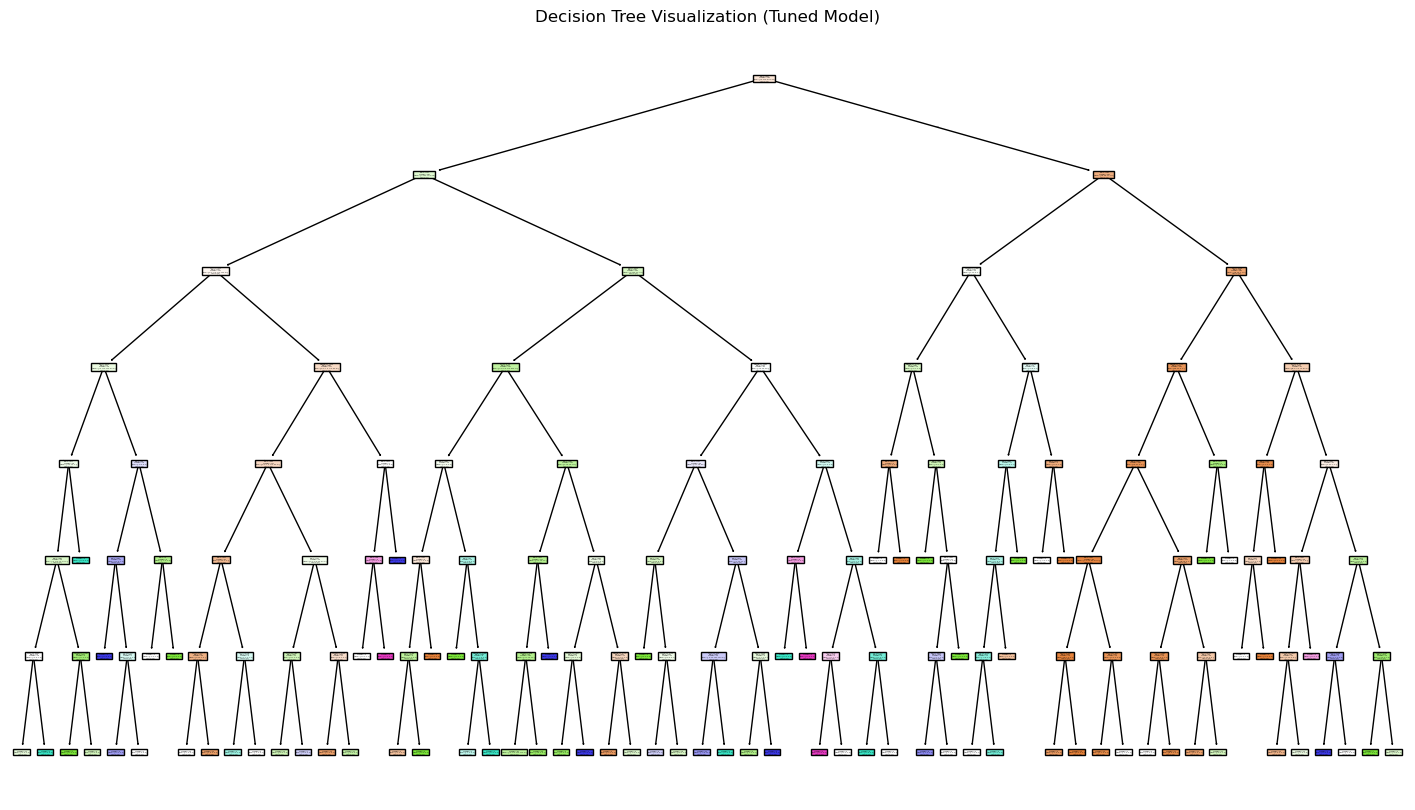

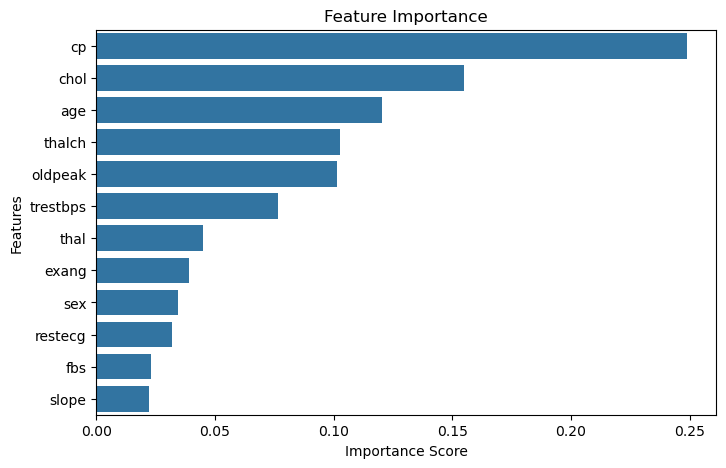

In [12]:
best_pred = best_model.predict(X_test)

print("\nTuned Decision Tree Performance:")
print("Accuracy :", accuracy_score(y_test, best_pred))
print("Precision:", precision_score(y_test, best_pred, average="macro"))
print("Recall   :", recall_score(y_test, best_pred, average="macro"))
print("F1 Score :", f1_score(y_test, best_pred, average="macro"))

# ------------------------------------------------------------
# Visualize Decision Tree Structure
# ------------------------------------------------------------

plt.figure(figsize=(18, 10))
plot_tree(
    best_model,
    feature_names=data.columns[:-1],
    filled=True,
    class_names=True)
plt.title("Decision Tree Visualization (Tuned Model)")
plt.show()

# ------------------------------------------------------------
# Feature Importance
# ------------------------------------------------------------

feature_importance = pd.Series(
    best_model.feature_importances_,
    index=data.columns[:-1]
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importance, y=feature_importance.index)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

## **Interview Questions**

**Common hyperparameters of decision tree models:**

- max_depth:
  Controls the maximum depth of the tree and prevents overfitting.

- min_samples_split:
  Minimum number of samples required to split an internal node.

- Determines how the quality of a split is measured (gini or entropy).


**Difference between Label Encoding and One-Hot Encoding**

Label Encoding assigns a unique numerical value to each category and is suitable for ordinal data.
One-Hot Encoding creates binary columns for each category and avoids introducing unintended
ordinal relationships, making it suitable for nominal categorical data.
